# ***Kodon Kullanım Frekanslarına Dayalı Çok Katmanlı Sınıflandırma:  Stacking Ensemble Yaklaşımı***

**Projenin Amacı**
Bu çalışmanın temel amacı, canlıların DNA dizilimlerindeki kodon kullanım frekanslarını (codon usage bias) analiz ederek, biyolojik taksonomideki Krallık (Kingdom) sınıflarını yüksek doğrulukla tahmin etmektir. Tek bir algoritmanın bakış açısına sınırlı kalmamak adına, bu projede farklı matematiksel temellere sahip modellerin güçlerini birleştiren Stacking (İstifleme) yöntemi kullanılmıştır.

**Neden Stacking Modeli Seçildi?**
Stacking, "Akıl akıldan üstündür" felsefesiyle çalışan, makine öğrenmesindeki en güçlü ensemble tekniklerinden biridir. Bu projede 3 farklı uzmanın görüşü alınarak nihai karara varılmaktadır:

***1. Çeşitlilik (Diversity) Stratejisi:***

*  **KNN (K-Nearest Neighbors):** Verinin geometrik ve uzaysal yakınlığını analiz eder.

*  **Random Forest:** Karar ağaçları topluluğu ile varyansı (değişkenliği) düşürür ve aşırı öğrenmeye karşı direnç sağlar.

*  **HistGradientBoosting:** Hataları optimize ederek ilerleyen boosting mantığıyla, verideki karmaşık ve doğrusal olmayan ilişkileri çözer.

***2.Meta-Öğrenme (The Meta-Learner):***

Yukarıdaki üç modelin tahminleri, bir Lojistik Regresyon modeline girdi olarak verilir. Bu "üst akıl", hangi durumda hangi modelin daha haklı olduğunu öğrenerek nihai sınıflandırmayı yapar.

In [1]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from IPython.display import display


sns.set_style("whitegrid")

Veri Seti Boyutu: (13028, 69)


C:\Users\fidan\AppData\Local\Temp\ipykernel_20224\1476341141.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')


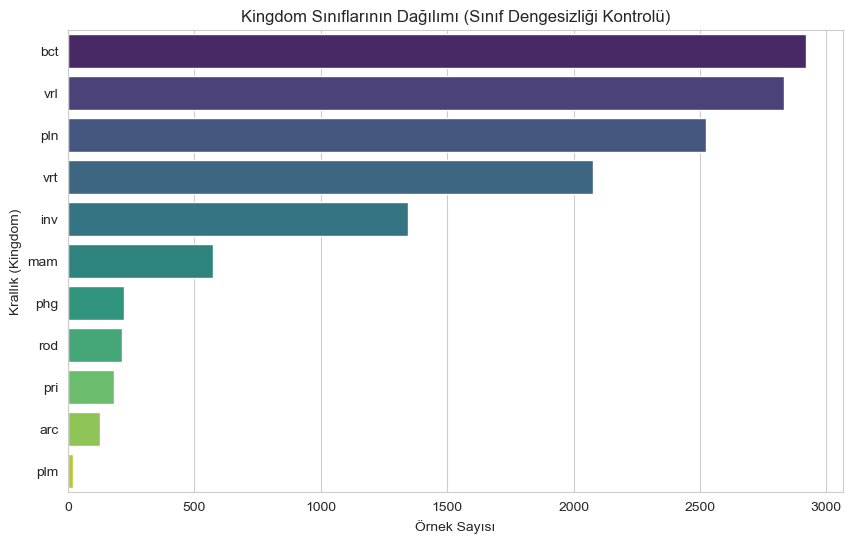

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [2]:
# Veri setini yükleme

df = pd.read_csv('C:\\Users\\fidan\\OneDrive\\Masaüstü\\codon_usage.csv', low_memory=False)  

print("Veri Seti Boyutu:", df.shape)

# Kingdom Sınıf Dağılımı grafik 
plt.figure(figsize=(10, 6))
sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')
plt.title('Kingdom Sınıflarının Dağılımı (Sınıf Dengesizliği Kontrolü)')
plt.xlabel('Örnek Sayısı')
plt.ylabel('Krallık (Kingdom)')
plt.show() 

# İlk 5 satırı göstermek için 
display(df.head())

### Veri Temizliği ve Tip Dönüşümü
Veri setindeki kodon frekansları bazen sayısal olması gerekirken "string" (metin) olarak algılanabilmektedir. Bu blokta:
*   Gereksiz sütunlar (`SpeciesID`, `SpeciesName`) atılır.
*   Sayısal sütunlardaki hatalı karakterler düzeltilir ve veri tipi sayısal formata (float) çevrilir.

In [3]:
codon_cols = df.columns[5:]

other_numeric_cols = ['Ncodons', 'DNAtype']
# Tüm sayısal özellikler
numeric_features = list(codon_cols) + other_numeric_cols

print("--- Temizlik Başlangıç (Virgülden Noktaya çevirme) ---")
for col in numeric_features:
    if df[col].dtype == 'object':
        # Virgülleri noktaya çevir, sayısal tipe zorlama, hataları NaN yapma adımı
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False), 
            errors="coerce"
        )
        
# İhtiyacımız olmayan tanımlayıcı sütunları çıkarıyoruz
df_cleaned = df.drop(columns=['SpeciesID', 'SpeciesName']).copy()

--- Temizlik Başlangıç (Virgülden Noktaya çevirme) ---


###  Veri Setinin Eğitim ve Test Olarak Ayrılması
Veri sızıntısını önlemek için veri seti, işlem yapılmadan önce %80 Eğitim ve %20 Test olarak ayrılır. Sınıf oranlarını korumak için `stratify` parametresi kullanılır.

In [4]:
#  Veri Ayırma (Split) 
X = df_cleaned.drop(columns=['Kingdom'])
y = df_cleaned['Kingdom']

# %80 Eğitim / %20 Test, Krallığa göre Katmanlı (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Eğitim ve test setlerini tek DataFrame'lerde birleştir 
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("\n--- Veri Ayırma Sonuçları ---")
print(f"X_train Boyutu: {X_train.shape}")
print(f"X_test Boyutu: {X_test.shape}")


--- Veri Ayırma Sonuçları ---
X_train Boyutu: (10422, 66)
X_test Boyutu: (2606, 66)


### Özellik Mühendisliği (Feature Engineering)
Mevcut verilerden yeni ve anlamlı bilgiler türetmek model başarısını artırabilir. 
Burada, DNA'daki toplam kodon sayısı (`Ncodons`) ile belirli bir kodonun (`UUU`) etkileşimini yakalamak amacıyla yeni bir özellik oluşturulmaktadır.

In [5]:

def create_interaction_feature(df):
    """Ncodons ve TTT kodon frekansı arasında çarpımsal etkileşim oluşturur."""
    
    df['Ncodons_x_UUU'] = df['Ncodons'] * df['UUU']
    return df

# Özellik yaratma işlemini train/test setlerine uygulama
train_df = create_interaction_feature(train_df)
test_df = create_interaction_feature(test_df)


numeric_features.append('Ncodons_x_UUU') 

print("\n Ncodons_x_UUU Etkileşim Özelliği Başarıyla Oluşturuldu.")



 Ncodons_x_UUU Etkileşim Özelliği Başarıyla Oluşturuldu.


### Eksik Verilerin Doldurulması ve Ölçeklendirme
*   Imputation: Eğitim setindeki eksik veriler, o sütunun ortalaması ile doldurulur. Test seti de (sızıntıyı önlemek için) eğitim setinin ortalaması ile doldurulur.
*   Encoding: Hedef değişken olan `Kingdom` sayısal değerlere dönüştürülür (Label Encoding).
*   Scaling: Veriler, ortalaması 0 ve standart sapması 1 olacak şekilde standartlaştırılır (StandardScaler). LDA gibi uzaklık ve varyans temelli algoritmalar için bu adım zorunludur.

In [6]:
train_means = train_df[numeric_features].mean()

# TRAIN ve TEST setlerini, TRAIN setinin ortalamaları ile dolduruyoruz.
train_df[numeric_features] = train_df[numeric_features].fillna(train_means)
test_df[numeric_features] = test_df[numeric_features].fillna(train_means)

print("\nEksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).")

# Encoding (Hedef Değişken Kodlama) 
le = LabelEncoder()
train_df['Kingdom_Encoded'] = le.fit_transform(train_df['Kingdom'])
test_df['Kingdom_Encoded'] = le.transform(test_df['Kingdom'])

print("Krallık Kodlaması:", dict(zip(le.classes_, le.transform(le.classes_))))

#  Scaling (Ölçeklendirme) 
scaler = StandardScaler()

scaler.fit(train_df[numeric_features])

# TRAIN ve TEST setlerini ölçekliyoruz.(TEST SADECE TRANSFORM)
train_df[numeric_features] = scaler.transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

print("Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).")


Eksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).
Krallık Kodlaması: {'arc': 0, 'bct': 1, 'inv': 2, 'mam': 3, 'phg': 4, 'plm': 5, 'pln': 6, 'pri': 7, 'rod': 8, 'vrl': 9, 'vrt': 10}
Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).


###  İşlenmiş Verinin Kaydedilmesi
Temizlenmiş ve modele girmeye hazır hale getirilmiş eğitim ve test setleri, daha sonraki aşamalarda (PCA, LDA vb.) tekrar tekrar işlem yapmamak adına ayrı dosyalar halinde kaydedilir.
Kaydedilen temiz veri setleri yüklenir ve LDA modellemesi ile özellik seçimi aşamalarına geçilir.

In [7]:
# X ve y setlerini oluşturma.
X_train_final = train_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_train_final = train_df['Kingdom_Encoded']
X_test_final = test_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_test_final = test_df['Kingdom_Encoded']

# Sonuçları CSV olarak kaydet
X_train_final.to_csv('X_train_final_KUSURSUZ.csv', index=False)
X_test_final.to_csv('X_test_final_KUSURSUZ.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_train_final.values, 'Kingdom_Original': train_df['Kingdom'].values}).to_csv('y_train_encoded_final_KUSURSUZ.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_test_final.values, 'Kingdom_Original': test_df['Kingdom'].values}).to_csv('y_test_encoded_final_KUSURSUZ.csv', index=False)

print("Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir.")

Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir.


In [8]:
# Kaydedilen veriler yüklenir

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, brier_score_loss


#  Veri Yükleme (Standardize Edilmiş) 
X_train = pd.read_csv('X_train_final_KUSURSUZ.csv')
X_test = pd.read_csv('X_test_final_KUSURSUZ.csv')
y_train = pd.read_csv('y_train_encoded_final_KUSURSUZ.csv')['Kingdom_Encoded']
y_test = pd.read_csv('y_test_encoded_final_KUSURSUZ.csv')['Kingdom_Encoded']
TARGET_CLASSES = len(y_test.unique())


### ***Stacking (İstifleme)*** Ensemble Modeli Kurulumu

Bu çalışmada, tek bir model yerine farklı matematiksel yapıdaki algoritmaların güçlerini birleştiren hibrit bir Stacking mimarisi kurulmuştur.

**Model Stratejisi (2 Katmanlı Yapı):**
1.  **Temel Öğreniciler (Base Learners):** Veriyi üç farklı "uzman" analiz eder:
    * **Random Forest:** Karar ağaçlarıyla varyansı düşürür ve dengesizliği yönetir.
    * **HistGradientBoosting:** Hataları optimize ederek öğrenen hızlı bir algoritmadır.
    * **KNN:** Verinin geometrik/uzaysal yapısını analiz ederek ağaç tabanlı modellerin kaçırdığı örüntüleri yakalar.
2.  **Meta Model (Final Estimator):** İlk katmanın tahminlerini birleştiren Lojistik Regresyon, hangi durumda hangi modele güveneceğine karar vererek nihai sonucu üretir.

**Teknik Önlem (Pipeline & Sızıntı Koruması):**
Her model, kendi içinde `StandardScaler` (Ölçekleme) ve `SimpleImputer` (Eksik Veri Tamamlama) işlemlerini yapan bir Pipeline içine alınmıştır. Bu yöntem, özellikle KNN için zorunlu olan ölçeklemeyi sağlarken, Veri Sızıntısını (Data Leakage) kesin olarak engeller.

In [9]:
#Gerekli Kütüphaneler 
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             roc_auc_score, matthews_corrcoef, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Temel model ve stacking kurulumu
print("Temel modeller (Uzmanlar) hazırlanıyor...")

# Uzman 1: Random Forest 
rf_pipe = make_pipeline(SimpleImputer(strategy='mean'), 
                        StandardScaler(),
                        RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1))

# Uzman 2: HistGradientBoosting
hgb_pipe = make_pipeline(SimpleImputer(strategy='mean'),
                         StandardScaler(),
                         HistGradientBoostingClassifier(random_state=42, class_weight='balanced', early_stopping=True))

# Uzman 3: KNN
knn_pipe = make_pipeline(SimpleImputer(strategy='mean'),
                         StandardScaler(),
                         KNeighborsClassifier()) # Komşu sayısını GridSearch ile bulacağız

estimators = [('rf', rf_pipe), ('hgb', hgb_pipe), ('knn', knn_pipe)]

# Stacking Modeli (Parametreleri GridSearch ile bulacağız)
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=2000),
    cv=3,
    n_jobs=-1
)

# Hiperparametre Tuning

print("Hiperparametre optimizasyonu başlatılıyor...")
print("Hem KNN komşu sayısı hem de Meta-Model (Lojistik Regresyon) ayarları deneniyor...")

# Stacking içinde parametre aramak için 'estimator_ismi__parametre' yapısı kullanılır.
param_grid = {
    'final_estimator__C': [0.1, 1.0, 10.0],
    'knn__kneighborsclassifier__n_neighbors': [5, 9] 
}

grid_search = GridSearchCV(
    estimator=stacking_clf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)

# Modeli Eğit
grid_search.fit(X_train, y_train)

# Sonuçları Raporla
print("\n" + "="*50)
print("EN İYİ STACKING PARAMETRELERİ")
print("="*50)
print(f"En İyi Skor (F1-Weighted CV): {grid_search.best_score_:.4f}")
print("Seçilen Parametreler:")
for param, val in grid_search.best_params_.items():
    print(f"  - {param}: {val}")

best_model = grid_search.best_estimator_

Temel modeller (Uzmanlar) hazırlanıyor...
Hiperparametre optimizasyonu başlatılıyor...
Hem KNN komşu sayısı hem de Meta-Model (Lojistik Regresyon) ayarları deneniyor...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

EN İYİ STACKING PARAMETRELERİ
En İyi Skor (F1-Weighted CV): 0.9204
Seçilen Parametreler:
  - final_estimator__C: 0.1
  - knn__kneighborsclassifier__n_neighbors: 5


###  Performans Değerlendirmesi ve Sonuçların Görselleştirilmesi

Bu bölümde, eğitilen Stacking (İstifleme) modelinin genelleme yeteneği, bağımsız Test Seti üzerinde analiz edilmiştir. Amaç, farklı modellerin "ortak aklının" (Ensemble), tekil modellere kıyasla hataları ne kadar düzelttiğini gözlemlemektir.

**Kullanılan Değerlendirme Kriterleri:**
* **MCC (Matthews Correlation Coefficient):** Sınıf dengesizliğinin olduğu veri setlerinde doğruluğa (Accuracy) göre çok daha güvenilir bir metriktir. Modelin şans faktöründen arındırılmış gerçek başarısını gösterir (+1: Mükemmel, 0: Rastgele).
* **Macro ROC AUC:** Modelin tüm sınıfları birbirinden ayırma kapasitesini ölçer. Stacking yapısının özellikle sınırda kalan örnekleri (borderline cases) ne kadar iyi ayrıştırdığını gösterir.
* **Confusion Matrix (Isı Haritası):** Modelin hangi sınıfları doğru bildiğini ve hangi sınıfları birbiriyle karıştırdığını görselleştirir.

Aşağıdaki kod bloğu, modelin tahminlerini üretmekte ve bu tahminleri istatistiksel grafiklere dönüştürmektedir.

Test seti üzerinde tahminler yapılıyor...

STACKING CLASSIFIER PERFORMANS RAPORU (OPTİMİZE EDİLMİŞ)
              precision    recall  f1-score   support

         arc     0.6364    0.8400    0.7241        25
         bct     0.9777    0.9024    0.9386       584
         inv     0.9145    0.9145    0.9145       269
         mam     0.9500    0.8333    0.8879       114
         phg     0.8000    0.8182    0.8090        44
         plm     0.1176    1.0000    0.2105         4
         pln     0.9486    0.9505    0.9496       505
         pri     0.7073    0.8056    0.7532        36
         rod     0.7391    0.7907    0.7640        43
         vrl     0.9552    0.9771    0.9660       567
         vrt     0.9685    0.9639    0.9662       415

    accuracy                         0.9309      2606
   macro avg     0.7923    0.8906    0.8076      2606
weighted avg     0.9427    0.9309    0.9356      2606

Matthews Correlation Coefficient (MCC): 0.9170
Macro Average ROC AUC Score       : 0.99

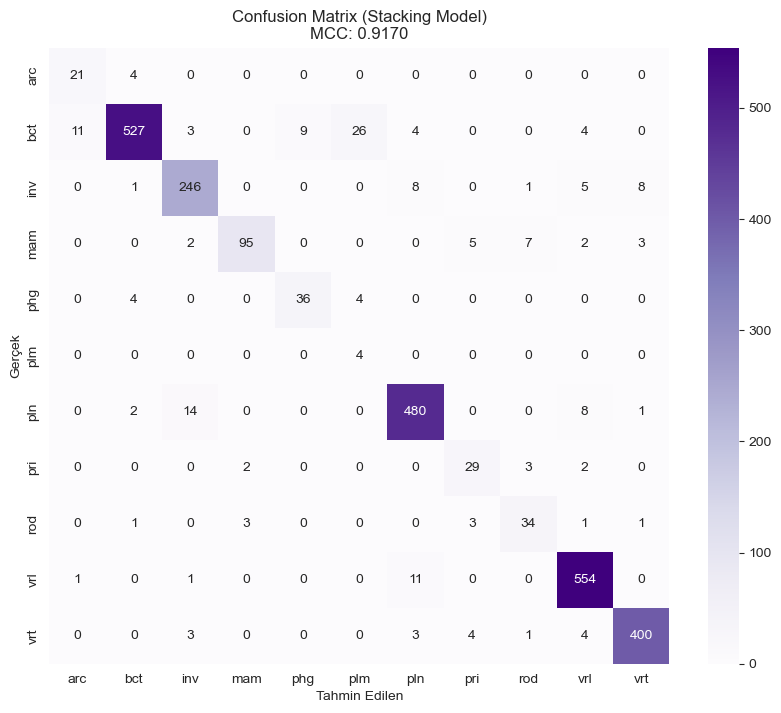

C:\Users\fidan\AppData\Local\Temp\ipykernel_20224\8880840.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


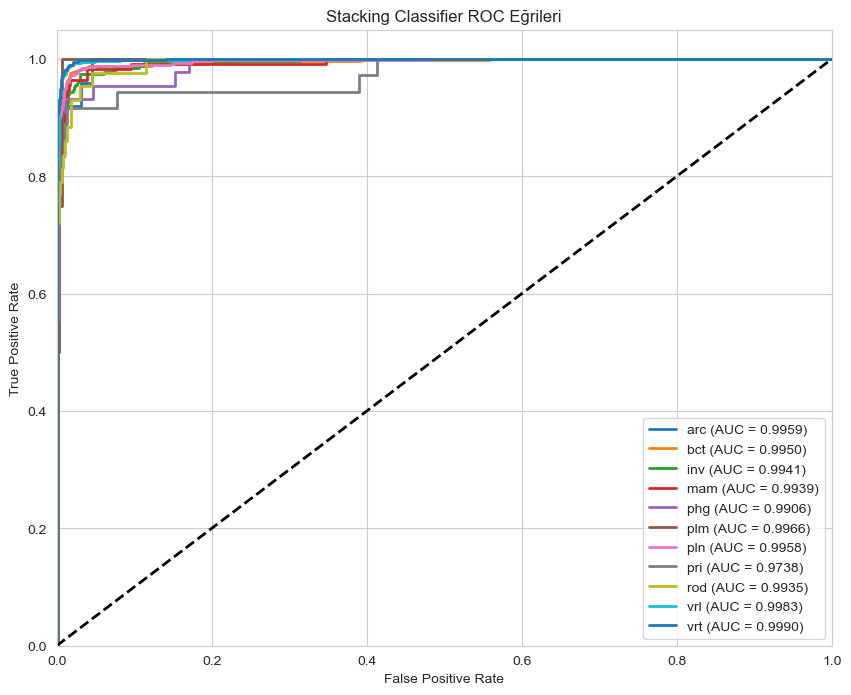

In [10]:
# Test ve görselleştirme

print("Test seti üzerinde tahminler yapılıyor...")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# -> Performans metrikleri
print("\n" + "="*80)
print("STACKING CLASSIFIER PERFORMANS RAPORU (OPTİMİZE EDİLMİŞ)")
print("="*80)

try:
    target_names = le.classes_
except NameError:
    target_names = [str(c) for c in np.unique(y_train)]

print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    print(f"Macro Average ROC AUC Score       : {roc_auc:.4f}")
except ValueError:
    print("ROC AUC hesaplanamadı.")

acc = accuracy_score(y_test, y_pred)
print(f"Genel Doğruluk (Accuracy)           : {acc:.4f}")
print("="*80)

# A) Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix (Stacking Model)\nMCC: {mcc:.4f}')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

# B) ROC Eğrileri
n_classes = len(target_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    if np.sum(y_test_bin[:, i]) > 0:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{target_names[i]} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacking Classifier ROC Eğrileri')
plt.legend(loc="lower right")
plt.show()